# Critical renewable-resource year — Punta Arenas, site-based analysis

This notebook compares the weather years configured in `YEARS` to identify a critical weather year for the Punta Arenas case study.

The main year selection uses one representative site: **Cabo Negro**, which represents the industrial/energy-relevant area close to Punta Arenas. Additional nearby Punta Arenas locations are used only for spatial complementarity diagnostics, not to select the critical year.

The daily classification follows a simple and transparent rule:

- **Both high**: wind and solar are above their thresholds.
- **Wind low / Solar high**: wind is below threshold, solar is above threshold.
- **Solar low / Wind high**: solar is below threshold, wind is above threshold.
- **Both low**: wind and solar are both below their thresholds.

The critical-year ranking is primarily based on the longest consecutive sequence of **both-low** days at the main site.


In [39]:
# Imports and configuration
import importlib
from pathlib import Path
import calendar
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

import config
config = importlib.reload(config)

# ── Case setup ───────────────────────────────────────────────────────────────
CASE_FOLDER = "input_punta_arenas"
CASE_NAME = "magallanes"
YEARS = list(range(2016, 2026))
if not YEARS:
    raise ValueError("YEARS must contain at least one weather year.")
YEAR_START = min(YEARS)
YEAR_END = max(YEARS)
YEAR_RANGE_LABEL = f"{YEAR_START}–{YEAR_END}"
YEAR_RANGE_SUFFIX = f"{YEAR_START}_{YEAR_END}"

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output_critical_weather_year")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# VRE assumptions: keep consistent with your cutout / case analysis notebooks
VRE_METHOD = "atlite_technology"
WIND_TURBINE = "Vestas_V112_3MW"
SOLAR_PANEL = "CSi"
SOLAR_ORIENTATION = "latitude_optimal"

# Same grid-lock setup used when the cutouts were created
DX = 0.25
DY = 0.25
GRID_LOCK_MODE = "fixed_bounds"
FIXED_BOUNDS = (-76.0, -66.0, -56.0, -50.0)  # Existing Magallanes cutout extent
REFERENCE_YEAR_FOR_GRID = 2020

# ── Analysis setup ───────────────────────────────────────────────────────────
# Main site used to select the critical weather year.
# Keep this fixed to avoid smoothing low-resource events across locations.
MAIN_SITE = "cabo_negro"

# Punta Arenas-focused strategic sites.
# These are intentionally kept close to the Punta Arenas supply/industrial area.
# They are not meant to represent all Magallanes.
#
# Important: at ERA5 0.25°, nearby locations may fall in the same grid cell.
# The next cells check this explicitly and warn if sites are effectively duplicated.
SITES = {
    # Main industrial / energy-relevant resource site
    "cabo_negro": {
        "lat": -52.966,
        "lon": -70.829,
        "group": "punta_arenas_core",
        "include_spatial": True,
        "role": "main_resource",
        "description": "Industrial and energy area north of Punta Arenas",
    },

    # Urban demand reference
    "punta_arenas_centro": {
        "lat": -53.163,
        "lon": -70.917,
        "group": "punta_arenas_core",
        "include_spatial": False,
        "role": "demand_reference",
        "description": "Urban demand reference",
    },

    # Optional spatial sensitivity
    "puente_tranquilo_sur": {
        "lat": -53.360,
        "lon": -70.980,
        "group": "punta_arenas_spatial_sensitivity",
        "include_spatial": True,
        "role": "southern_resource_sensitivity",
        "description": "Southern coastal sensitivity close to Punta Arenas",
    },

    # Kept for diagnostics only; likely same/equivalent ERA5 resource cell as Cabo Negro
    "chabunco_aeropuerto": {
        "lat": -53.003,
        "lon": -70.854,
        "group": "diagnostic_only",
        "include_spatial": False,
        "role": "duplicate_check",
        "description": "Airport / northern corridor; not used as independent model node",
    },

    "rio_seco_laredo": {
        "lat": -53.080,
        "lon": -70.870,
        "group": "diagnostic_only",
        "include_spatial": False,
        "role": "duplicate_check",
        "description": "Río Seco / Laredo local area; not used as independent model node",
    },
}
SPATIAL_SITES = [name for name, spec in SITES.items() if spec.get("include_spatial", True)]
if MAIN_SITE not in SPATIAL_SITES:
    SPATIAL_SITES = [MAIN_SITE] + SPATIAL_SITES

# Low-resource thresholds used for daily classification.
# Keep these simple and explicit for the paper; run the sensitivity section if needed.
LOW_WIND_THRESHOLD = 0.20
LOW_SOLAR_THRESHOLD = 0.10

# ── Publication figure settings ───────────────────────────────────────────────
PAPER_DPI = 300
CM_TO_INCH = 1 / 2.54
WORD_SINGLE_COL_IN = 8.0 * CM_TO_INCH
WORD_DOUBLE_COL_IN = 16.0 * CM_TO_INCH

FIGSIZE_PALETTE = (WORD_DOUBLE_COL_IN, 1.2)
FIGSIZE_WIDE = (WORD_DOUBLE_COL_IN, 3.6)
FIGSIZE_STANDARD = (WORD_DOUBLE_COL_IN, 4.4)
FIGSIZE_TALL = (WORD_DOUBLE_COL_IN, 5.0)
FIGSIZE_HEATMAP = (WORD_DOUBLE_COL_IN, 5.2)
FIGSIZE_COMBINED = (WORD_DOUBLE_COL_IN, 6.25)

FONT_SIZE_BASE = 9
FONT_SIZE_SMALL = 8
FONT_SIZE_LABEL = 9
FONT_SIZE_PANEL = 9

plt.rcParams.update({
    "font.size": FONT_SIZE_BASE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "axes.titlesize": FONT_SIZE_BASE,
    "xtick.labelsize": FONT_SIZE_SMALL,
    "ytick.labelsize": FONT_SIZE_SMALL,
    "legend.fontsize": FONT_SIZE_SMALL,
})

# Plot controls
PLOT_EACH_YEAR = True             # scatter + monthly strip for all years at MAIN_SITE
PLOT_TOP_N_YEARS = 3              # additional focus plots for top-ranked years; set 0 to skip
PLOT_SPATIAL_COMPARISON = True    # spatial comparison for the selected critical year
PLOT_COMPLEMENTARITY = True       # wind-solar and spatial complementarity diagnostics
PLOT_CF_DISTRIBUTIONS = True      # violin/strip plots for daily CF distributions

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print(f"Case: {CASE_NAME}")
print(f"Years: {YEARS[0]}-{YEARS[-1]}")
print(f"Main site for year ranking: {MAIN_SITE}")
print(f"Spatial sites used for Punta Arenas comparison: {SPATIAL_SITES}")
print(f"Wind threshold: {LOW_WIND_THRESHOLD:.2f}")
print(f"Solar threshold: {LOW_SOLAR_THRESHOLD:.2f}")
print(f"Outputs: {OUTPUT_DIR}")


Case: magallanes
Years: 2016-2025
Main site for year ranking: cabo_negro
Spatial sites used for Punta Arenas comparison: ['cabo_negro', 'puente_tranquilo_sur']
Wind threshold: 0.20
Solar threshold: 0.10
Outputs: output_critical_weather_year


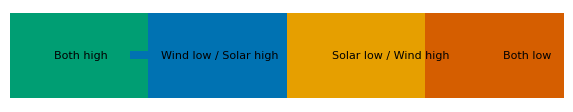

In [40]:

# Colorblind-friendly palette used for the classification plots
# Okabe-Ito palette: widely used colorblind-safe qualitative palette.

OKABE_ITO = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000",
}

category_order = [
    "both_high",
    "wind_low_solar_high",
    "solar_low_wind_high",
    "both_low",
]

category_labels = {
    "both_high": "Both high",
    "wind_low_solar_high": "Wind low / Solar high",
    "solar_low_wind_high": "Solar low / Wind high",
    "both_low": "Both low",
}

category_colors = {
    "both_high": OKABE_ITO["bluish_green"],       # green
    "wind_low_solar_high": OKABE_ITO["blue"],    # blue
    "solar_low_wind_high": OKABE_ITO["orange"],  # orange
    "both_low": OKABE_ITO["vermillion"],         # red-orange
}

tech_colors = {
    "wind": OKABE_ITO["blue"],
    "solar": OKABE_ITO["orange"],
    "threshold": OKABE_ITO["black"],
}

# Quick visual check
fig, ax = plt.subplots(figsize=FIGSIZE_PALETTE)
for i, category in enumerate(category_order):
    ax.barh([0], [1], left=[i], color=category_colors[category], label=category_labels[category])
ax.set_xlim(0, len(category_order))
ax.set_yticks([])
ax.set_xticks([])
ax.legend(ncol=4, loc="center", frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


In [41]:
# Load nodes and define site dataframe
import xarray as xr

paths = config.get_case_paths(CASE_FOLDER)
nodes_df = config.load_nodes_from_csv(paths["csv_nodes"])

if nodes_df is None or nodes_df.empty:
    raise ValueError("Nodes CSV is empty or missing.")
if not {"lat", "lon"}.issubset(nodes_df.columns):
    raise ValueError("Nodes CSV must include lat and lon columns.")

valid_coords = nodes_df[["lat", "lon"]].dropna()
if valid_coords.empty:
    raise ValueError("No valid lat/lon coordinates found in nodes CSV.")

# Site dataframe used by config.get_vre_profiles_from_cutout.
# It mimics the node table but contains selected strategic locations.
sites_df = pd.DataFrame(
    [
        {
            "zone": name,
            "lat": spec["lat"],
            "lon": spec["lon"],
            "group": spec.get("group", ""),
            "include_spatial": bool(spec.get("include_spatial", True)),
            "description": spec.get("description", ""),
        }
        for name, spec in SITES.items()
    ]
)

if MAIN_SITE not in set(sites_df["zone"]):
    raise ValueError(f"MAIN_SITE={MAIN_SITE!r} not found in SITES keys: {list(SITES)}")

missing_spatial_sites = sorted(set(SPATIAL_SITES) - set(sites_df["zone"]))
if missing_spatial_sites:
    raise ValueError(f"These SPATIAL_SITES are missing from SITES: {missing_spatial_sites}")

padding_deg = 1.0
derived_bounds = (
    float(valid_coords["lon"].min()) - padding_deg,
    float(valid_coords["lon"].max()) + padding_deg,
    float(valid_coords["lat"].min()) - padding_deg,
    float(valid_coords["lat"].max()) + padding_deg,
)

if GRID_LOCK_MODE == "fixed_bounds":
    lock_bounds = tuple(float(v) for v in FIXED_BOUNDS)
    lock_dx = float(DX)
    lock_dy = float(DY)
elif GRID_LOCK_MODE == "match_existing_year":
    ref_path = DATA_DIR / f"{CASE_NAME}_{REFERENCE_YEAR_FOR_GRID}.nc"
    if not ref_path.exists():
        raise FileNotFoundError(f"Reference cutout not found: {ref_path}")
    with xr.open_dataset(ref_path) as ds_ref:
        x_vals = np.array(ds_ref["x"].values)
        y_vals = np.array(ds_ref["y"].values)
        lock_bounds = (
            float(np.min(x_vals)),
            float(np.max(x_vals)),
            float(np.min(y_vals)),
            float(np.max(y_vals)),
        )
        lock_dx = float(np.median(np.diff(np.sort(np.unique(x_vals)))))
        lock_dy = float(np.median(np.diff(np.sort(np.unique(y_vals)))))
else:
    lock_bounds = derived_bounds
    lock_dx = float(DX)
    lock_dy = float(DY)

print("Original model nodes:")
display(nodes_df[["zone", "lat", "lon"]])

print("\nPunta Arenas-focused sites used in this notebook:")
display(sites_df)

print("\nSpatial sites included in the comparison figures:")
display(sites_df[sites_df["zone"].isin(SPATIAL_SITES)])

print("\nCanonical grid:")
print(f"bounds={lock_bounds}")
print(f"dx={lock_dx}, dy={lock_dy}")


Original model nodes:


,zone,lat,lon
0,punta_arenas_centro,-53.163,-70.917
1,cabo_negro,-52.966,-70.829



Punta Arenas-focused sites used in this notebook:


,zone,lat,lon,group,include_spatial,description
0,cabo_negro,-52.966,-70.829,punta_arenas_core,True,Industrial and energy area north of Punta Arenas
1,punta_arenas_centro,-53.163,-70.917,punta_arenas_core,False,Urban demand reference
2,puente_tranquilo_sur,-53.360,-70.980,punta_arenas_spatial_sensitivity,True,Southern coastal sensitivity close to Punta Ar...
3,chabunco_aeropuerto,-53.003,-70.854,diagnostic_only,False,Airport / northern corridor; not used as indep...
4,rio_seco_laredo,-53.080,-70.870,diagnostic_only,False,Río Seco / Laredo local area; not used as inde...



Spatial sites included in the comparison figures:


,zone,lat,lon,group,include_spatial,description
0,cabo_negro,-52.966,-70.829,punta_arenas_core,True,Industrial and energy area north of Punta Arenas
2,puente_tranquilo_sur,-53.360,-70.980,punta_arenas_spatial_sensitivity,True,Southern coastal sensitivity close to Punta Ar...



Canonical grid:
bounds=(-76.0, -66.0, -56.0, -50.0)
dx=0.25, dy=0.25


In [42]:
# Check which ERA5 grid cell each strategic site maps to
# This is useful because points that are too close may fall in the same 0.25° cell.

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c


def nearest_grid_cell_for_site(ds, lat, lon):
    x_vals = np.asarray(ds["x"].values, dtype=float)
    y_vals = np.asarray(ds["y"].values, dtype=float)
    nearest_lon = float(x_vals[np.argmin(np.abs(x_vals - lon))])
    nearest_lat = float(y_vals[np.argmin(np.abs(y_vals - lat))])
    dist_km = haversine_km(lat, lon, nearest_lat, nearest_lon)
    return nearest_lat, nearest_lon, dist_km

# Use the first available cutout to map sites to cells
first_existing_cutout = None
for y in YEARS:
    p = DATA_DIR / f"{CASE_NAME}_{y}.nc"
    if p.exists():
        first_existing_cutout = p
        break

if first_existing_cutout is None:
    raise FileNotFoundError(f"No cutout files found in {DATA_DIR} for {CASE_NAME}_YYYY.nc")

cell_rows = []
with xr.open_dataset(first_existing_cutout) as ds:
    for _, row in sites_df.iterrows():
        grid_lat, grid_lon, dist_km = nearest_grid_cell_for_site(ds, row["lat"], row["lon"])
        cell_rows.append({
            "site": row["zone"],
            "group": row.get("group", ""),
            "include_spatial": bool(row.get("include_spatial", True)),
            "description": row.get("description", ""),
            "site_lat": row["lat"],
            "site_lon": row["lon"],
            "era5_grid_lat": grid_lat,
            "era5_grid_lon": grid_lon,
            "distance_to_grid_cell_km": dist_km,
            "grid_cell_id": f"{grid_lat:.3f}_{grid_lon:.3f}",
        })

site_grid_df = pd.DataFrame(cell_rows)
site_grid_csv = TABLES_DIR / f"{CASE_NAME}_punta_arenas_sites_era5_grid_cells.csv"
site_grid_df.to_csv(site_grid_csv, index=False)

print(f"Grid-cell mapping based on: {first_existing_cutout}")
print(f"Saved: {site_grid_csv}")
display(site_grid_df)

duplicated_cells = (
    site_grid_df[site_grid_df["include_spatial"]]
    .groupby("grid_cell_id")["site"]
    .apply(list)
    .reset_index()
)
duplicated_cells = duplicated_cells[duplicated_cells["site"].apply(len) > 1]

if not duplicated_cells.empty:
    print("\nWarning: some spatial-comparison sites fall in the same ERA5 grid cell.")
    print("They may produce identical or nearly identical wind/solar CF profiles.")
    display(duplicated_cells)
else:
    print("\nAll included spatial-comparison sites map to different ERA5 grid cells.")


Grid-cell mapping based on: data\magallanes_2016.nc
Saved: output_critical_weather_year\tables\magallanes_punta_arenas_sites_era5_grid_cells.csv


,site,group,include_spatial,description,site_lat,site_lon,era5_grid_lat,era5_grid_lon,distance_to_grid_cell_km,grid_cell_id
0,cabo_negro,punta_arenas_core,True,Industrial and energy area north of Punta Arenas,-52.966,-70.829,-53.00,-70.75,6.501008,-53.000_-70.750
1,punta_arenas_centro,punta_arenas_core,False,Urban demand reference,-53.163,-70.917,-53.25,-71.00,11.141833,-53.250_-71.000
2,puente_tranquilo_sur,punta_arenas_spatial_sensitivity,True,Southern coastal sensitivity close to Punta Ar...,-53.360,-70.980,-53.25,-71.00,12.303420,-53.250_-71.000
3,chabunco_aeropuerto,diagnostic_only,False,Airport / northern corridor; not used as indep...,-53.003,-70.854,-53.00,-70.75,6.967301,-53.000_-70.750
4,rio_seco_laredo,diagnostic_only,False,Río Seco / Laredo local area; not used as inde...,-53.080,-70.870,-53.00,-70.75,11.979024,-53.000_-70.750



All included spatial-comparison sites map to different ERA5 grid cells.


In [43]:

# Helper functions

def savefig(fig, filename, dpi=PAPER_DPI):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


def longest_true_run(mask_array: np.ndarray) -> int:
    max_run = 0
    run = 0
    for value in np.asarray(mask_array).astype(bool):
        if value:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return int(max_run)


def longest_true_run_dates(mask_series: pd.Series):
    s = mask_series.astype(bool).dropna()
    if s.empty or not s.any():
        return 0, pd.NaT, pd.NaT

    best_len = 0
    best_start = None
    best_end = None
    current_len = 0
    current_start = None

    for timestamp, value in s.items():
        if value:
            if current_len == 0:
                current_start = timestamp
            current_len += 1
            if current_len > best_len:
                best_len = current_len
                best_start = current_start
                best_end = timestamp
        else:
            current_len = 0
            current_start = None

    return int(best_len), best_start, best_end


def classify_wind_solar_days(df: pd.DataFrame,
                             wind_threshold: float,
                             solar_threshold: float) -> pd.DataFrame:
    out = df.copy()
    out["wind_low"] = out["wind_cf"] < wind_threshold
    out["solar_low"] = out["solar_cf"] < solar_threshold
    out["both_low"] = out["wind_low"] & out["solar_low"]

    out["category"] = np.select(
        [
            out["both_low"],
            out["wind_low"] & ~out["solar_low"],
            ~out["wind_low"] & out["solar_low"],
        ],
        ["both_low", "wind_low_solar_high", "solar_low_wind_high"],
        default="both_high",
    )
    return out


def compute_metrics(classified_df: pd.DataFrame, year: int, site: str) -> dict:
    both_len, both_start, both_end = longest_true_run_dates(classified_df["both_low"])
    wind_len, wind_start, wind_end = longest_true_run_dates(classified_df["wind_low"])
    solar_len, solar_start, solar_end = longest_true_run_dates(classified_df["solar_low"])

    monthly_both_runs = []
    monthly_both_days = []
    for m in range(1, 13):
        m_df = classified_df[classified_df.index.month == m]
        if m_df.empty:
            monthly_both_runs.append(0)
            monthly_both_days.append(0)
        else:
            monthly_both_runs.append(longest_true_run(m_df["both_low"].to_numpy()))
            monthly_both_days.append(int(m_df["both_low"].sum()))

    category_counts = classified_df["category"].value_counts().reindex(category_order, fill_value=0)

    return {
        "site": site,
        "year": int(year),
        "days": int(len(classified_df)),
        "wind_cf_mean": float(classified_df["wind_cf"].mean()),
        "solar_cf_mean": float(classified_df["solar_cf"].mean()),
        "both_low_days": int(category_counts["both_low"]),
        "wind_low_solar_high_days": int(category_counts["wind_low_solar_high"]),
        "solar_low_wind_high_days": int(category_counts["solar_low_wind_high"]),
        "both_high_days": int(category_counts["both_high"]),
        "both_low_share": float(category_counts["both_low"] / len(classified_df)),
        "max_consecutive_both_low_days": both_len,
        "max_both_low_start": both_start.strftime("%Y-%m-%d") if pd.notna(both_start) else "",
        "max_both_low_end": both_end.strftime("%Y-%m-%d") if pd.notna(both_end) else "",
        "max_consecutive_wind_low_days": wind_len,
        "max_wind_low_start": wind_start.strftime("%Y-%m-%d") if pd.notna(wind_start) else "",
        "max_wind_low_end": wind_end.strftime("%Y-%m-%d") if pd.notna(wind_end) else "",
        "max_consecutive_solar_low_days": solar_len,
        "max_solar_low_start": solar_start.strftime("%Y-%m-%d") if pd.notna(solar_start) else "",
        "max_solar_low_end": solar_end.strftime("%Y-%m-%d") if pd.notna(solar_end) else "",
        "worst_month_both_low_run": int(max(monthly_both_runs)),
        "worst_month_both_low_days": int(max(monthly_both_days)),
        "worst_month_by_run": month_labels[int(np.argmax(monthly_both_runs))],
        "worst_month_by_days": month_labels[int(np.argmax(monthly_both_days))],
    }


def prepare_daily_site_df(wind_cf: pd.DataFrame, solar_cf: pd.DataFrame, year: int) -> pd.DataFrame:
    rows = []
    for site in wind_cf.columns:
        daily = pd.DataFrame({
            "wind_cf": wind_cf[site].resample("D").mean(),
            "solar_cf": solar_cf[site].resample("D").mean(),
        }).dropna()
        daily = classify_wind_solar_days(daily, LOW_WIND_THRESHOLD, LOW_SOLAR_THRESHOLD)
        daily["year"] = int(year)
        daily["site"] = site
        daily["month"] = daily.index.month
        daily["day"] = daily.index.day
        daily["dayofyear"] = daily.index.dayofyear
        rows.append(daily)
    return pd.concat(rows).sort_index()


def plot_scatter(df, title, filename_prefix, x_label_site=True):
    fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)

    for category in category_order:
        subset = df[df["category"] == category]
        if subset.empty:
            continue
        ax.scatter(
            subset["wind_cf"],
            subset["solar_cf"],
            s=26,
            alpha=0.85,
            color=category_colors[category],
            label=category_labels[category],
        )

    ax.axvline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1.0)
    ax.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1.0)
    ax.set_xlabel("Daily mean wind capacity factor [-]")
    ax.set_ylabel("Daily mean solar capacity factor [-]")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=FONT_SIZE_SMALL)
    plt.tight_layout()
    savefig(fig, f"{filename_prefix}_wind_vs_solar_daily_scatter.png")
    plt.show()


def plot_monthly_strip(calendar_df, year, title, filename_prefix):
    fig, ax = plt.subplots(figsize=FIGSIZE_TALL)
    row_height = 0.66
    month_sequence = list(range(1, 13))
    y_positions = {month: len(month_sequence) - idx for idx, month in enumerate(month_sequence)}

    x_left, x_right = 0.0, 1.0
    total_row_width = x_right - x_left

    for month in month_sequence:
        y = y_positions[month]
        n_days = calendar.monthrange(int(year), month)[1]
        day_width = total_row_width / n_days
        gap = day_width * 0.08

        month_data = calendar_df[calendar_df["month"] == month]
        for _, row in month_data.iterrows():
            d = int(row["day"])
            x0 = x_left + (d - 1) * day_width + gap / 2
            rect = Rectangle(
                (x0, y - row_height / 2),
                day_width - gap,
                row_height,
                facecolor=category_colors[row["category"]],
                edgecolor="white",
                linewidth=0.6,
            )
            ax.add_patch(rect)

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(0.35, len(month_sequence) + 0.9)
    ax.set_yticks([y_positions[m] for m in month_sequence])
    ax.set_yticklabels(month_labels, fontsize=FONT_SIZE_BASE)
    ax.set_xticks([])
    ax.set_title(title, pad=42)
    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    legend_handles = [
        Patch(facecolor=category_colors[category], edgecolor="none", label=category_labels[category])
        for category in category_order
        if (calendar_df["category"] == category).any()
    ]
    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        frameon=False,
        fontsize=FONT_SIZE_SMALL,
        handlelength=1.2,
        handleheight=1.2,
        columnspacing=1.8,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    savefig(fig, f"{filename_prefix}_monthly_daily_category_strip.png")
    plt.show()


In [44]:

# Compute daily wind/solar CF for all strategic sites and years
# The year ranking below will use only MAIN_SITE, but this table is useful for spatial comparisons.

all_daily_sites = []
missing_years = []

for year in YEARS:
    cutout_file = DATA_DIR / f"{CASE_NAME}_{year}.nc"
    if not cutout_file.exists():
        print(f"Missing cutout for {year}: {cutout_file}")
        missing_years.append(year)
        continue

    print(f"Processing {year}...")
    cutout = config.get_case_cutout(
        year=year,
        force_prepare=False,
        base_dir="data",
        case_name=CASE_NAME,
        bounds=lock_bounds,
        nodes_df=sites_df,
        dx=lock_dx,
        dy=lock_dy,
    )

    wind_cf, solar_cf = config.get_vre_profiles_from_cutout(
        cutout=cutout,
        nodes_df=sites_df,
        method=VRE_METHOD,
        wind_turbine=WIND_TURBINE,
        solar_panel=SOLAR_PANEL,
        solar_orientation=SOLAR_ORIENTATION,
    )

    # Ensure site columns are strings and consistent
    wind_cf.columns = wind_cf.columns.astype(str)
    solar_cf.columns = solar_cf.columns.astype(str)

    daily_sites = prepare_daily_site_df(wind_cf, solar_cf, year)
    all_daily_sites.append(daily_sites)

if not all_daily_sites:
    raise RuntimeError("No valid cutouts found. Check DATA_DIR, CASE_NAME, and year file names.")

daily_sites_df = pd.concat(all_daily_sites).sort_values(["site", "year"])
daily_sites_csv = TABLES_DIR / f"{CASE_NAME}_daily_wind_solar_categories_by_site_{YEAR_RANGE_SUFFIX}.csv"
daily_sites_df.to_csv(daily_sites_csv)

print(f"Saved: {daily_sites_csv}")
if missing_years:
    print(f"Missing years skipped: {missing_years}")

display(daily_sites_df.head())


Processing 2016...


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Processing 2017...


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Processing 2018...


...

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Processing 2025...


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Saved: output_critical_weather_year\tables\magallanes_daily_wind_solar_categories_by_site_2016_2025.csv


,wind_cf,solar_cf,wind_low,solar_low,both_low,category,year,site,month,day,dayofyear
2016-01-01,0.027206,0.244161,True,False,False,wind_low_solar_high,2016,cabo_negro,1,1,1
2016-01-02,0.649592,0.213913,False,False,False,both_high,2016,cabo_negro,1,2,2
2016-01-03,0.716120,0.198517,False,False,False,both_high,2016,cabo_negro,1,3,3
2016-01-04,0.555554,0.128575,False,False,False,both_high,2016,cabo_negro,1,4,4
2016-01-05,0.998730,0.168627,False,False,False,both_high,2016,cabo_negro,1,5,5


In [45]:

# Main analysis: compare years at one representative site
main_daily_df = daily_sites_df[daily_sites_df["site"] == MAIN_SITE].copy()
if main_daily_df.empty:
    raise RuntimeError(f"No daily data found for MAIN_SITE={MAIN_SITE}")

summary_rows = []
for year, group in main_daily_df.groupby("year"):
    summary_rows.append(compute_metrics(group, int(year), MAIN_SITE))

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["max_consecutive_both_low_days", "both_low_days", "max_consecutive_wind_low_days"],
    ascending=[False, False, False],
).reset_index(drop=True)
summary_df.insert(0, "rank", np.arange(1, len(summary_df) + 1))

critical_year = int(summary_df.loc[0, "year"])
critical_start = summary_df.loc[0, "max_both_low_start"]
critical_end = summary_df.loc[0, "max_both_low_end"]

summary_csv = TABLES_DIR / f"{CASE_NAME}_{MAIN_SITE}_critical_weather_year_summary_{YEAR_RANGE_SUFFIX}.csv"
main_daily_csv = TABLES_DIR / f"{CASE_NAME}_{MAIN_SITE}_daily_wind_solar_categories_{YEAR_RANGE_SUFFIX}.csv"
summary_df.to_csv(summary_csv, index=False)
main_daily_df.to_csv(main_daily_csv)

print(f"Saved: {summary_csv}")
print(f"Saved: {main_daily_csv}")
print(f"\nSelected critical year at {MAIN_SITE}: {critical_year}")
print(f"Longest both-low sequence: {summary_df.loc[0, 'max_consecutive_both_low_days']} days ({critical_start} to {critical_end})")

display(summary_df)


Saved: output_critical_weather_year\tables\magallanes_cabo_negro_critical_weather_year_summary_2016_2025.csv
Saved: output_critical_weather_year\tables\magallanes_cabo_negro_daily_wind_solar_categories_2016_2025.csv

Selected critical year at cabo_negro: 2020
Longest both-low sequence: 9 days (2020-06-28 to 2020-07-06)


,rank,site,year,days,wind_cf_mean,solar_cf_mean,both_low_days,wind_low_solar_high_days,solar_low_wind_high_days,both_high_days,...,max_consecutive_wind_low_days,max_wind_low_start,max_wind_low_end,max_consecutive_solar_low_days,max_solar_low_start,max_solar_low_end,worst_month_both_low_run,worst_month_both_low_days,worst_month_by_run,worst_month_by_days
0,1,cabo_negro,2020,366,0.576391,0.122746,36,30,123,177,...,9,2020-06-28,2020-07-06,14,2020-06-28,2020-07-11,6,11,Jul,Jul
1,2,cabo_negro,2025,365,0.599775,0.132440,32,29,92,212,...,8,2025-07-26,2025-08-02,20,2025-06-02,2025-06-21,6,8,Jun,Jun
2,3,cabo_negro,2018,365,0.583196,0.131558,27,34,100,204,...,12,2018-09-18,2018-09-29,9,2018-05-05,2018-05-13,6,9,Jun,Jun
3,4,cabo_negro,2016,366,0.554993,0.133308,39,33,89,205,...,8,2016-07-29,2016-08-05,22,2016-06-09,2016-06-30,4,14,May,May
4,5,cabo_negro,2019,365,0.607227,0.130868,22,28,112,203,...,5,2019-07-07,2019-07-11,23,2019-06-28,2019-07-20,5,10,Jul,Jul
5,6,cabo_negro,2024,366,0.588746,0.126300,42,24,99,201,...,5,2024-05-06,2024-05-10,12,2024-05-27,2024-06-07,4,17,May,Jun
6,7,cabo_negro,2021,365,0.609905,0.129196,30,26,112,197,...,4,2021-07-14,2021-07-17,21,2021-06-15,2021-07-05,4,7,Jul,May
7,8,cabo_negro,2022,365,0.607838,0.132339,24,26,112,203,...,4,2022-07-03,2022-07-06,10,2022-05-30,2022-06-08,3,7,Jul,Jul
8,9,cabo_negro,2023,365,0.644045,0.134559,18,12,117,218,...,3,2023-06-20,2023-06-22,28,2023-06-08,2023-07-05,3,6,Jun,Jun
9,10,cabo_negro,2017,365,0.604786,0.129612,21,34,119,191,...,8,2017-03-27,2017-04-03,12,2017-05-21,2017-06-01,2,7,May,May


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_criticality_ranking_both_low_streak_2016_2025.png


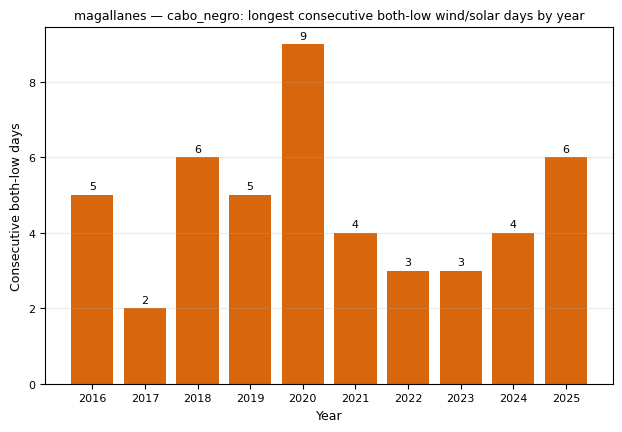

In [46]:

# Plot 1: criticality ranking across years at MAIN_SITE
plot_df = summary_df.sort_values("year")

fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)
ax.bar(
    plot_df["year"].astype(str),
    plot_df["max_consecutive_both_low_days"],
    color=category_colors["both_low"],
    alpha=0.95,
)
ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: longest consecutive both-low wind/solar days by year")
ax.set_xlabel("Year")
ax.set_ylabel("Consecutive both-low days")
ax.grid(True, axis="y", alpha=0.25)

for x, y in zip(plot_df["year"].astype(str), plot_df["max_consecutive_both_low_days"]):
    ax.text(x, y + 0.1, str(int(y)), ha="center", va="bottom", fontsize=FONT_SIZE_SMALL)

plt.tight_layout()
savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_criticality_ranking_both_low_streak_{YEAR_RANGE_SUFFIX}.png")
plt.show()


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_daily_category_counts_2016_2025.png


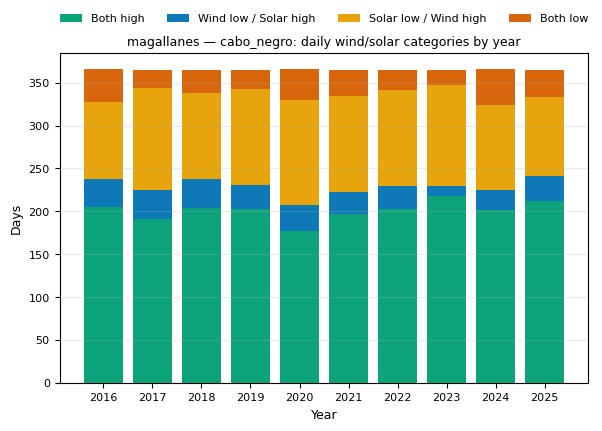

In [47]:

# Plot 2: stacked category counts by year at MAIN_SITE
counts_cols = [
    "both_high_days",
    "wind_low_solar_high_days",
    "solar_low_wind_high_days",
    "both_low_days",
]
counts_plot = summary_df.sort_values("year").set_index("year")[counts_cols]

label_map_counts = {
    "both_high_days": "Both high",
    "wind_low_solar_high_days": "Wind low / Solar high",
    "solar_low_wind_high_days": "Solar low / Wind high",
    "both_low_days": "Both low",
}
color_map_counts = {
    "both_high_days": category_colors["both_high"],
    "wind_low_solar_high_days": category_colors["wind_low_solar_high"],
    "solar_low_wind_high_days": category_colors["solar_low_wind_high"],
    "both_low_days": category_colors["both_low"],
}

fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)
bottom = np.zeros(len(counts_plot))
x = np.arange(len(counts_plot))

for col in counts_cols:
    ax.bar(
        x,
        counts_plot[col].values,
        bottom=bottom,
        color=color_map_counts[col],
        label=label_map_counts[col],
        alpha=0.95,
    )
    bottom += counts_plot[col].values

ax.set_xticks(x)
ax.set_xticklabels(counts_plot.index.astype(str))
ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: daily wind/solar categories by year")
ax.set_xlabel("Year")
ax.set_ylabel("Days")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.15))
plt.tight_layout()
savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_daily_category_counts_{YEAR_RANGE_SUFFIX}.png")
plt.show()


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2016_wind_vs_solar_daily_scatter.png


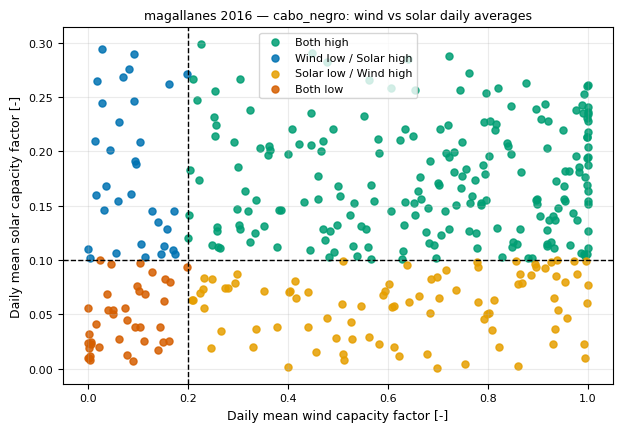

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2016_monthly_daily_category_strip.png


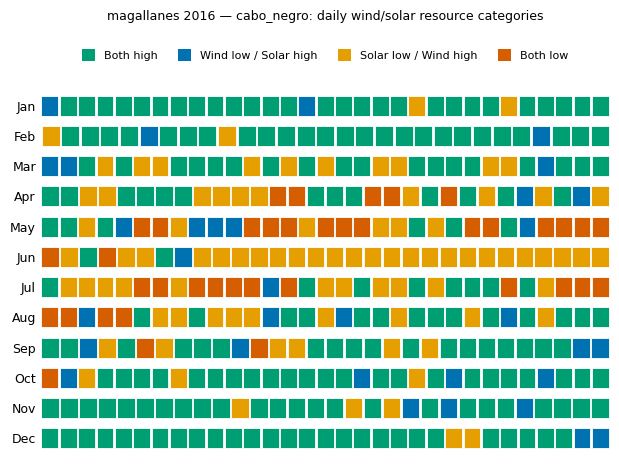

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2017_wind_vs_solar_daily_scatter.png


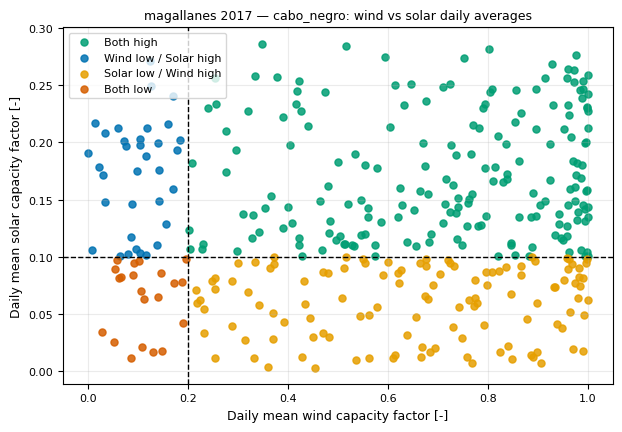

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2017_monthly_daily_category_strip.png


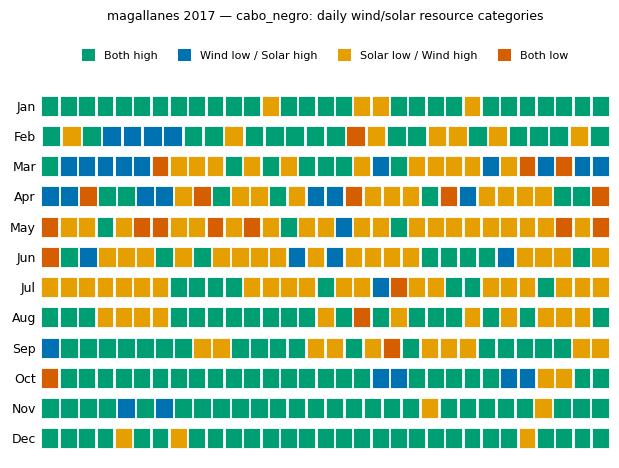

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2018_wind_vs_solar_daily_scatter.png


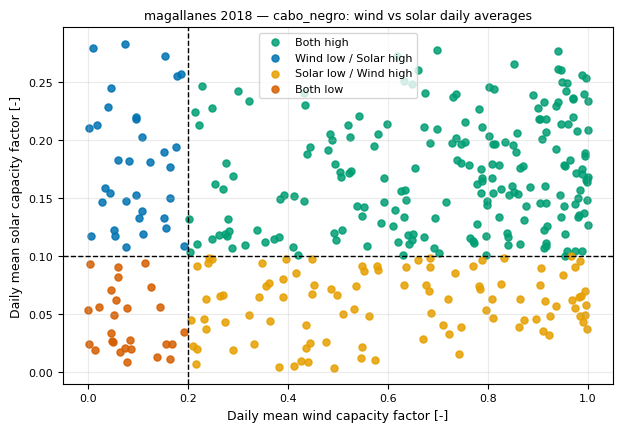

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2018_monthly_daily_category_strip.png


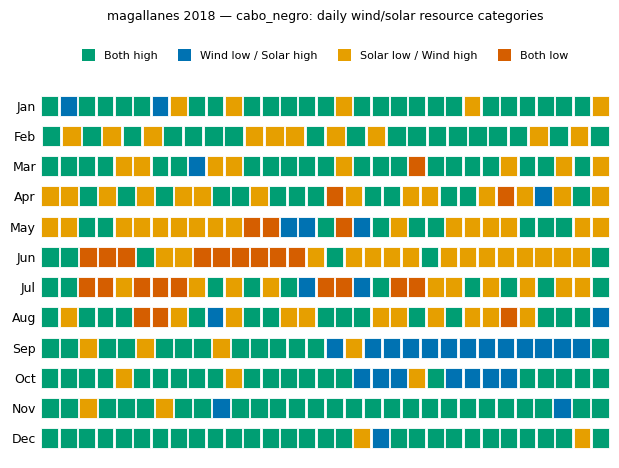

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2019_wind_vs_solar_daily_scatter.png


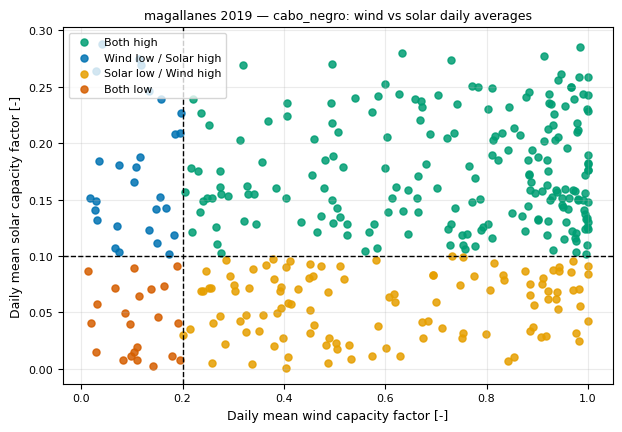

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2019_monthly_daily_category_strip.png


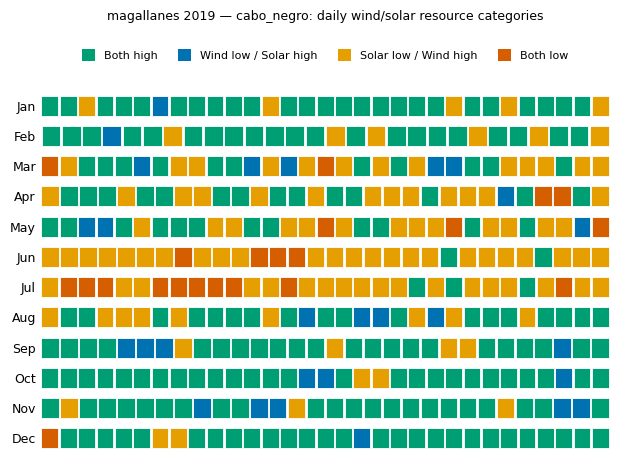

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2020_wind_vs_solar_daily_scatter.png


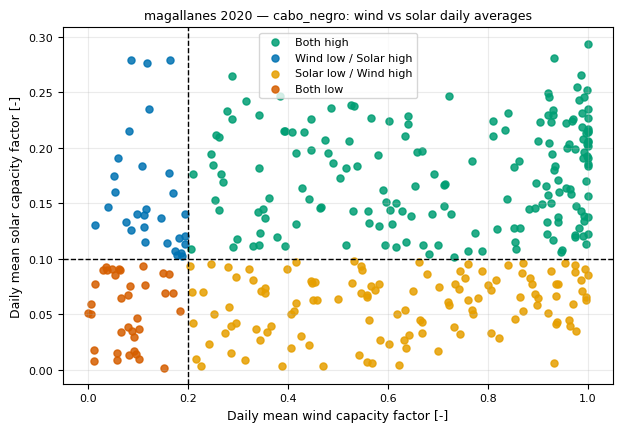

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2020_monthly_daily_category_strip.png


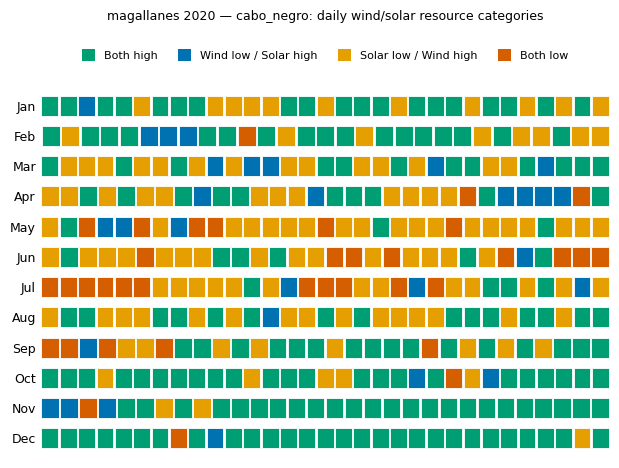

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2021_wind_vs_solar_daily_scatter.png


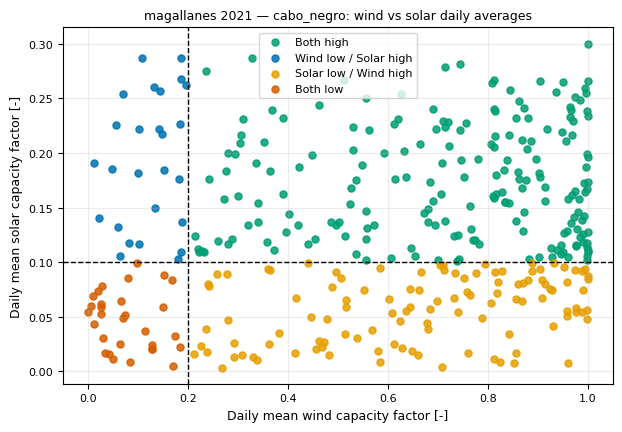

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2021_monthly_daily_category_strip.png


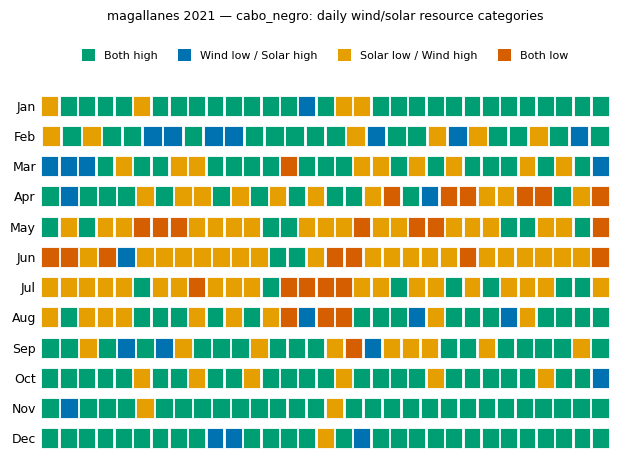

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2022_wind_vs_solar_daily_scatter.png


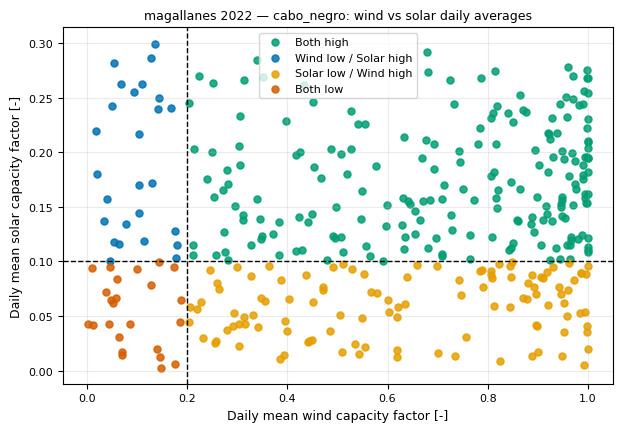

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2022_monthly_daily_category_strip.png


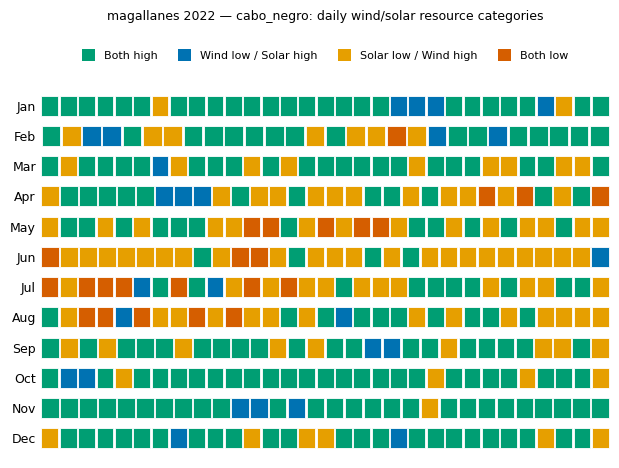

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2023_wind_vs_solar_daily_scatter.png


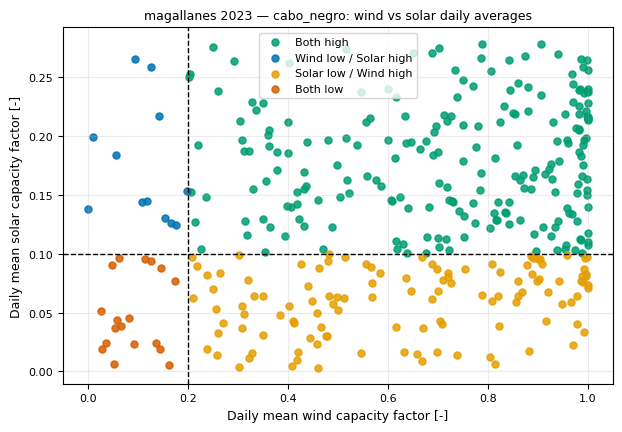

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2023_monthly_daily_category_strip.png


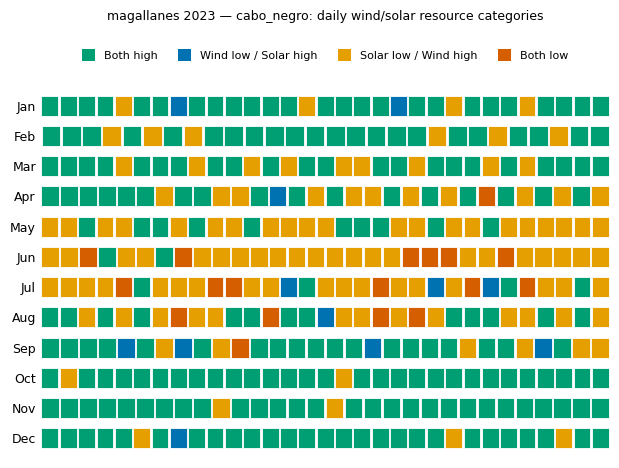

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2024_wind_vs_solar_daily_scatter.png


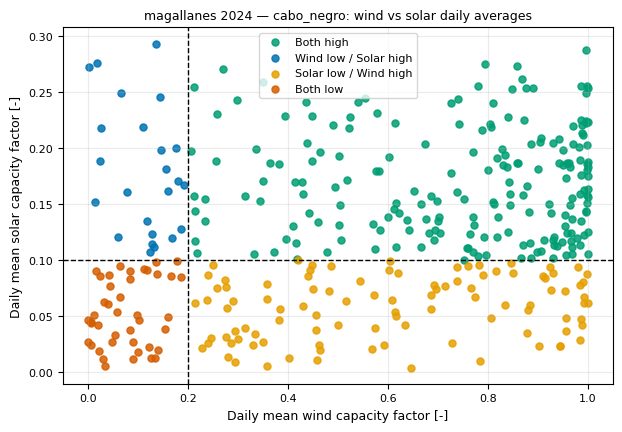

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2024_monthly_daily_category_strip.png


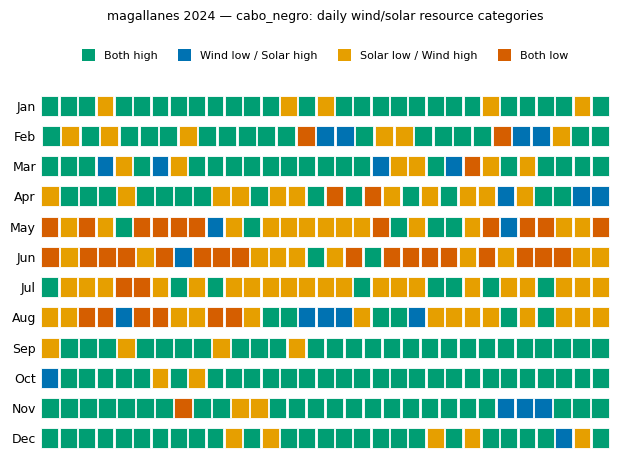

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2025_wind_vs_solar_daily_scatter.png


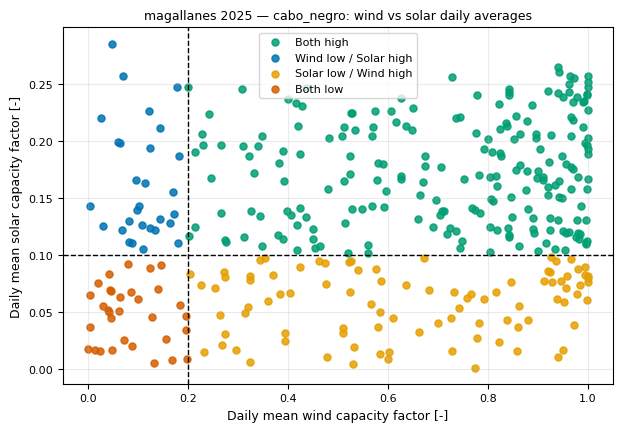

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2025_monthly_daily_category_strip.png


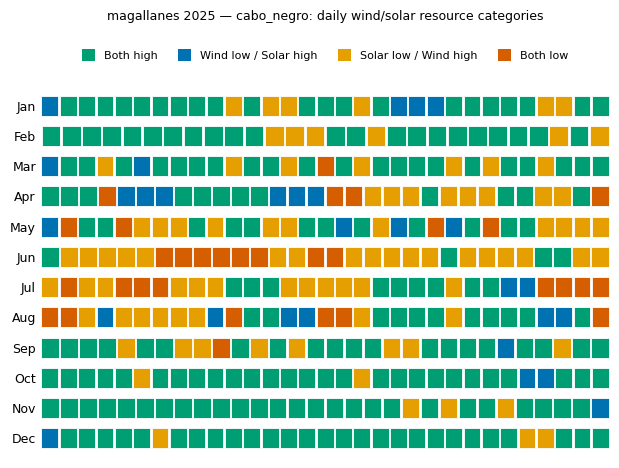

In [48]:

# Plot 3: wind vs solar scatter and monthly strips for each year at MAIN_SITE
if PLOT_EACH_YEAR:
    for year in sorted(main_daily_df["year"].unique()):
        year_df = main_daily_df[main_daily_df["year"] == year].copy()
        prefix = f"{CASE_NAME}_{MAIN_SITE}_{year}"
        plot_scatter(
            year_df,
            title=f"{CASE_NAME} {year} — {MAIN_SITE}: wind vs solar daily averages",
            filename_prefix=prefix,
        )
        plot_monthly_strip(
            year_df,
            year=year,
            title=f"{CASE_NAME} {year} — {MAIN_SITE}: daily wind/solar resource categories",
            filename_prefix=prefix,
        )


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_category_strips_all_years_2016_2025.png


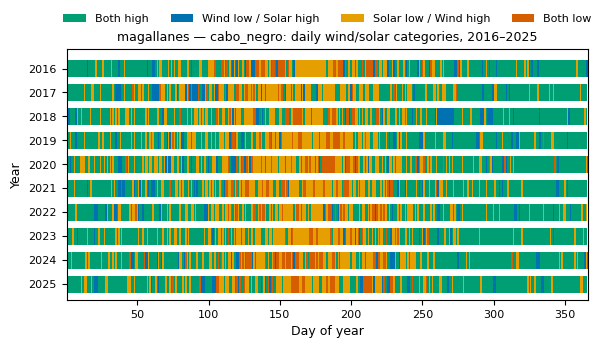

In [49]:

# Plot 4: compact category strips across all configured years at MAIN_SITE
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
years_sorted = sorted(main_daily_df["year"].unique())
y_positions = {year: len(years_sorted) - i for i, year in enumerate(years_sorted)}
row_height = 0.72

for year in years_sorted:
    y = y_positions[year]
    year_df = main_daily_df[main_daily_df["year"] == year].copy()
    for _, row in year_df.iterrows():
        d = int(row["dayofyear"])
        rect = Rectangle(
            (d - 0.5, y - row_height / 2),
            1.0,
            row_height,
            facecolor=category_colors[row["category"]],
            edgecolor="none",
        )
        ax.add_patch(rect)

ax.set_xlim(0.5, 366.5)
ax.set_ylim(0.35, len(years_sorted) + 0.8)
ax.set_yticks([y_positions[y] for y in years_sorted])
ax.set_yticklabels([str(y) for y in years_sorted])
ax.set_xlabel("Day of year")
ax.set_ylabel("Year")
ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: daily wind/solar categories, {YEAR_RANGE_LABEL}")
ax.grid(False)

legend_handles = [Patch(facecolor=category_colors[c], edgecolor="none", label=category_labels[c]) for c in category_order]
ax.legend(handles=legend_handles, ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.tight_layout()
savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_category_strips_all_years_{YEAR_RANGE_SUFFIX}.png")
plt.show()


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_critical_weather_panel_2016_2025.png
Saved: output_critical_weather_year\figures\magallanes_cabo_negro_critical_weather_panel_2016_2025.svg
Saved: output_critical_weather_year\figures\magallanes_cabo_negro_critical_weather_panel_2016_2025.pdf


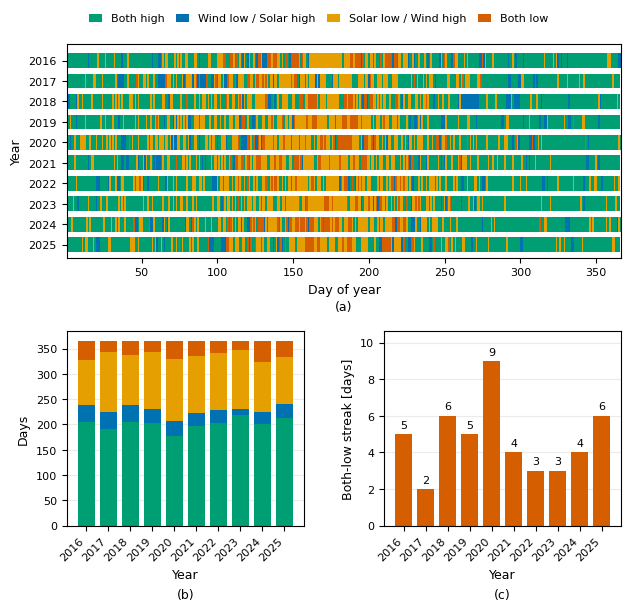

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# Combined critical-weather figure
# (a) daily category strips across years
# (b) annual category counts
# (c) longest consecutive both-low period
# ─────────────────────────────────────────────────────────────────────────────

required_objects = [
    "main_daily_df",
    "summary_df",
    "category_order",
    "category_labels",
    "category_colors",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the preceding analysis cells first. Missing objects: "
        + ", ".join(missing_objects)
    )


# ── Data preparation ─────────────────────────────────────────────────────────
years_sorted = sorted(
    main_daily_df["year"].unique()
)

summary_plot = (
    summary_df
    .sort_values("year")
    .set_index("year")
    .reindex(years_sorted)
)


# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(
    figsize=FIGSIZE_COMBINED
)

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1.10, 1.0],
    hspace=0.36,
    wspace=0.34,
)

ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])


# ── (a) Daily category strips ────────────────────────────────────────────────
y_positions = {
    year: len(years_sorted) - i
    for i, year in enumerate(years_sorted)
}

row_height = 0.72

for year in years_sorted:
    y = y_positions[year]

    year_df = main_daily_df[
        main_daily_df["year"] == year
    ]

    for _, row in year_df.iterrows():
        day = int(row["dayofyear"])

        ax_a.add_patch(
            Rectangle(
                (day - 0.5, y - row_height / 2),
                1.0,
                row_height,
                facecolor=category_colors[row["category"]],
                edgecolor="none",
            )
        )

ax_a.set_xlim(
    0.5,
    366.5,
)

ax_a.set_ylim(
    0.35,
    len(years_sorted) + 0.8,
)

ax_a.set_yticks([
    y_positions[year]
    for year in years_sorted
])

ax_a.set_yticklabels([
    str(year)
    for year in years_sorted
])

ax_a.set_xlabel(
    "Day of year",
    labelpad=4,
)

ax_a.set_ylabel("Year")
ax_a.grid(False)


# ── (b) Annual category distribution ────────────────────────────────────────
count_columns = {
    "both_high": "both_high_days",
    "wind_low_solar_high": "wind_low_solar_high_days",
    "solar_low_wind_high": "solar_low_wind_high_days",
    "both_low": "both_low_days",
}

x = np.arange(
    len(years_sorted)
)

bottom = np.zeros(
    len(years_sorted)
)

for category in category_order:
    values = (
        summary_plot[count_columns[category]]
        .fillna(0.0)
        .to_numpy()
    )

    ax_b.bar(
        x,
        values,
        bottom=bottom,
        color=category_colors[category],
        edgecolor="none",
        width=0.78,
    )

    bottom += values

ax_b.set_xticks(x)

ax_b.set_xticklabels(
    years_sorted,
    rotation=45,
    ha="right",
)

ax_b.set_xlabel(
    "Year",
    labelpad=4,
)

ax_b.set_ylabel("Days")

ax_b.grid(
    axis="y",
    alpha=0.25,
)

ax_b.set_axisbelow(True)


# ── (c) Longest consecutive both-low sequence ───────────────────────────────
streak_values = (
    summary_plot["max_consecutive_both_low_days"]
    .fillna(0.0)
    .to_numpy()
)

bars = ax_c.bar(
    x,
    streak_values,
    color=category_colors["both_low"],
    edgecolor="none",
    width=0.78,
)

ax_c.set_xticks(x)

ax_c.set_xticklabels(
    years_sorted,
    rotation=45,
    ha="right",
)

ax_c.set_xlabel(
    "Year",
    labelpad=4,
)

ax_c.set_ylabel(
    "Both-low streak [days]"
)

ax_c.grid(
    axis="y",
    alpha=0.25,
)

ax_c.set_axisbelow(True)

label_offset = max(
    0.15,
    0.025 * max(
        streak_values.max(),
        1.0,
    ),
)

for bar, value in zip(
    bars,
    streak_values,
):
    ax_c.text(
        bar.get_x() + bar.get_width() / 2,
        value + label_offset,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=FONT_SIZE_SMALL,
    )

ax_c.set_ylim(
    0,
    max(
        1.0,
        streak_values.max() * 1.18,
    ),
)


# ── Shared legend ────────────────────────────────────────────────────────────
legend_handles = [
    Patch(
        facecolor=category_colors[category],
        edgecolor="none",
        label=category_labels[category],
    )
    for category in category_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=4,
    frameon=False,
    fontsize=FONT_SIZE_SMALL,
    columnspacing=1.0,
    handlelength=1.2,
)


# ── Final spacing ────────────────────────────────────────────────────────────
fig.subplots_adjust(
    top=0.92,
    bottom=0.15,
    left=0.10,
    right=0.98,
)


# ── Panel labels ─────────────────────────────────────────────────────────────
upper_position = ax_a.get_position()

upper_center_x = (
    upper_position.x0 + upper_position.x1
) / 2

upper_bottom = upper_position.y0

lower_top = max(
    ax_b.get_position().y1,
    ax_c.get_position().y1,
)

panel_a_y = lower_top + 0.48 * (
    upper_bottom - lower_top - 0.035
)

fig.text(
    upper_center_x,
    panel_a_y,
    "(a)",
    ha="center",
    va="center",
    fontsize=FONT_SIZE_PANEL,
)

# Place (b) and (c) below the lower panels.
for axis, label in [
    (ax_b, "(b)"),
    (ax_c, "(c)"),
]:
    position = axis.get_position()

    fig.text(
        (position.x0 + position.x1) / 2,
        position.y0 - 0.1,
        label,
        ha="center",
        va="top",
        fontsize=FONT_SIZE_PANEL,
    )


# ── Export ───────────────────────────────────────────────────────────────────
panel_name = (
    f"{CASE_NAME}_{MAIN_SITE}_critical_weather_panel_"
    f"{YEAR_RANGE_SUFFIX}"
)

savefig(
    fig,
    f"{panel_name}.png",
)

savefig(
    fig,
    f"{panel_name}.svg",
)

savefig(
    fig,
    f"{panel_name}.pdf",
)

plt.show()

Top 3 critical years at cabo_negro: [2020, 2025, 2018]
Saved: output_critical_weather_year\figures\magallanes_cabo_negro_top3_critical_years_wind_cf.png


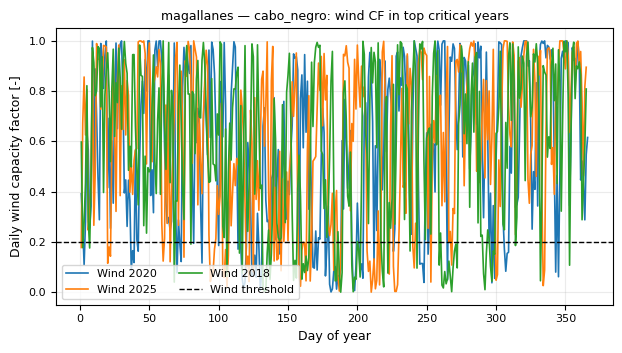

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_top3_critical_years_solar_cf.png


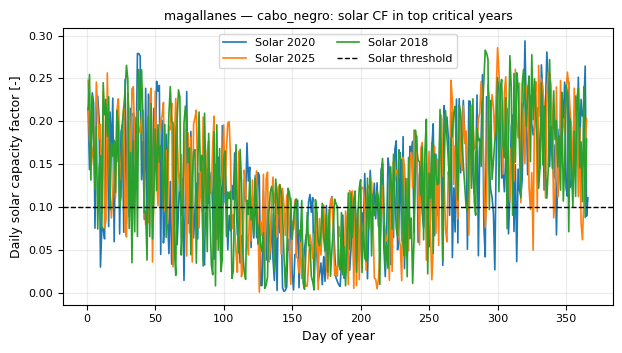

In [51]:

# Optional focus plots for top-ranked years at MAIN_SITE
if PLOT_TOP_N_YEARS and PLOT_TOP_N_YEARS > 0:
    top_years = summary_df.head(PLOT_TOP_N_YEARS)["year"].astype(int).tolist()
    print(f"Top {PLOT_TOP_N_YEARS} critical years at {MAIN_SITE}: {top_years}")

    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    for year in top_years:
        year_df = main_daily_df[main_daily_df["year"] == year].copy()
        ax.plot(year_df["dayofyear"], year_df["wind_cf"], label=f"Wind {year}", linewidth=1.2)
    ax.axhline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1.0, label="Wind threshold")
    ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: wind CF in top critical years")
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Daily wind capacity factor [-]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=FONT_SIZE_SMALL)
    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_top{PLOT_TOP_N_YEARS}_critical_years_wind_cf.png")
    plt.show()

    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    for year in top_years:
        year_df = main_daily_df[main_daily_df["year"] == year].copy()
        ax.plot(year_df["dayofyear"], year_df["solar_cf"], label=f"Solar {year}", linewidth=1.2)
    ax.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1.0, label="Solar threshold")
    ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: solar CF in top critical years")
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Daily solar capacity factor [-]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=FONT_SIZE_SMALL)
    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_top{PLOT_TOP_N_YEARS}_critical_years_solar_cf.png")
    plt.show()



## Spatial comparison during the selected critical year

The next section compares the strategic sites using the **same selected critical year** from the main-site analysis. This is not used to choose the critical year; it is a complementary test of whether low-resource periods are spatially synchronized or partially diversified across the region.


In [52]:
# Spatial comparison for the selected critical year
# This section only uses the Punta Arenas-focused sites listed in SPATIAL_SITES.
# It is not used to choose the critical year; the year is selected from MAIN_SITE.

if PLOT_SPATIAL_COMPARISON:
    spatial_daily_df = daily_sites_df[
        (daily_sites_df["year"] == critical_year)
        & (daily_sites_df["site"].isin(SPATIAL_SITES))
    ].copy()

    if spatial_daily_df.empty:
        raise RuntimeError("No spatial data found. Check SPATIAL_SITES and daily_sites_df.")

    spatial_summary_rows = []
    for site, group in spatial_daily_df.groupby("site"):
        spatial_summary_rows.append(compute_metrics(group, critical_year, site))

    spatial_summary_df = pd.DataFrame(spatial_summary_rows)

    # Keep requested order where possible, then rank by criticality for the table
    spatial_summary_df["site_order"] = spatial_summary_df["site"].map({s: i for i, s in enumerate(SPATIAL_SITES)})
    spatial_summary_df = spatial_summary_df.sort_values(
        ["max_consecutive_both_low_days", "both_low_days", "max_consecutive_wind_low_days"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    spatial_summary_df.insert(0, "rank", np.arange(1, len(spatial_summary_df) + 1))

    spatial_summary_csv = TABLES_DIR / f"{CASE_NAME}_punta_arenas_spatial_comparison_{critical_year}_summary.csv"
    spatial_daily_csv = TABLES_DIR / f"{CASE_NAME}_punta_arenas_spatial_comparison_{critical_year}_daily_categories.csv"
    spatial_summary_df.drop(columns=["site_order"], errors="ignore").to_csv(spatial_summary_csv, index=False)
    spatial_daily_df.to_csv(spatial_daily_csv)

    print(f"Critical year selected from {MAIN_SITE}: {critical_year}")
    print(f"Sites included: {SPATIAL_SITES}")
    print(f"Saved: {spatial_summary_csv}")
    print(f"Saved: {spatial_daily_csv}")
    display(spatial_summary_df.drop(columns=["site_order"], errors="ignore"))


Critical year selected from cabo_negro: 2020
Sites included: ['cabo_negro', 'puente_tranquilo_sur']
Saved: output_critical_weather_year\tables\magallanes_punta_arenas_spatial_comparison_2020_summary.csv
Saved: output_critical_weather_year\tables\magallanes_punta_arenas_spatial_comparison_2020_daily_categories.csv


,rank,site,year,days,wind_cf_mean,solar_cf_mean,both_low_days,wind_low_solar_high_days,solar_low_wind_high_days,both_high_days,...,max_consecutive_wind_low_days,max_wind_low_start,max_wind_low_end,max_consecutive_solar_low_days,max_solar_low_start,max_solar_low_end,worst_month_both_low_run,worst_month_both_low_days,worst_month_by_run,worst_month_by_days
0,1,puente_tranquilo_sur,2020,366,0.519461,0.122802,52,32,106,176,...,9,2020-06-28,2020-07-06,14,2020-06-28,2020-07-11,6,14,Jun,Jul
1,2,cabo_negro,2020,366,0.576391,0.122746,36,30,123,177,...,9,2020-06-28,2020-07-06,14,2020-06-28,2020-07-11,6,11,Jul,Jul


Saved: output_critical_weather_year\figures\magallanes_spatial_ranking_both_low_streak_2020.png


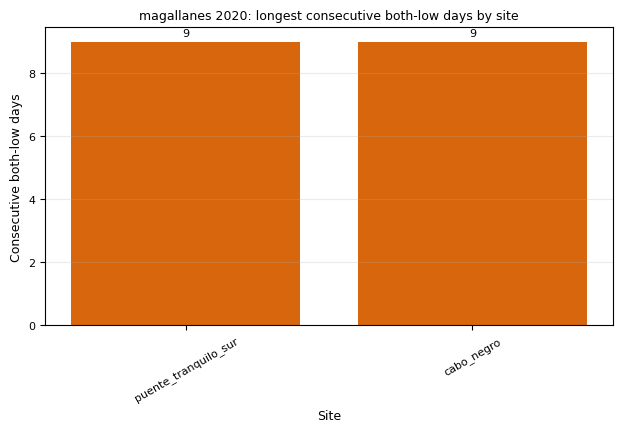

In [53]:

# Spatial plot 1: criticality ranking by site during the selected critical year
if PLOT_SPATIAL_COMPARISON:
    plot_df = spatial_summary_df.copy()

    fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)
    ax.bar(
        plot_df["site"],
        plot_df["max_consecutive_both_low_days"],
        color=category_colors["both_low"],
        alpha=0.95,
    )
    ax.set_title(f"{CASE_NAME} {critical_year}: longest consecutive both-low days by site")
    ax.set_xlabel("Site")
    ax.set_ylabel("Consecutive both-low days")
    ax.grid(True, axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

    for x, y in zip(plot_df["site"], plot_df["max_consecutive_both_low_days"]):
        ax.text(x, y + 0.1, str(int(y)), ha="center", va="bottom", fontsize=FONT_SIZE_SMALL)

    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_spatial_ranking_both_low_streak_{critical_year}.png")
    plt.show()


Saved: output_critical_weather_year\figures\magallanes_spatial_category_strips_2020.png


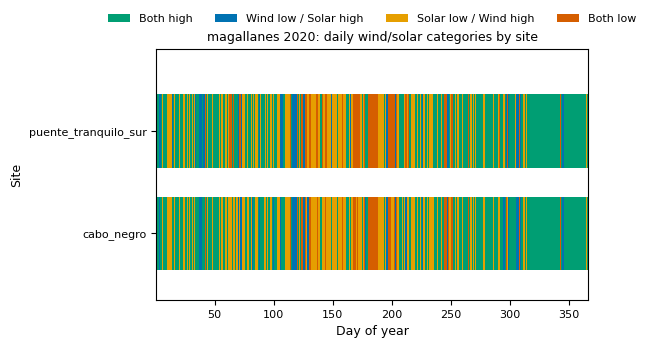

In [54]:

# Spatial plot 2: compact category strips by site during the selected critical year
if PLOT_SPATIAL_COMPARISON:
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    sites_sorted = spatial_summary_df["site"].tolist()
    y_positions = {site: len(sites_sorted) - i for i, site in enumerate(sites_sorted)}
    row_height = 0.72

    for site in sites_sorted:
        y = y_positions[site]
        site_df = spatial_daily_df[spatial_daily_df["site"] == site].copy()
        for _, row in site_df.iterrows():
            d = int(row["dayofyear"])
            rect = Rectangle(
                (d - 0.5, y - row_height / 2),
                1.0,
                row_height,
                facecolor=category_colors[row["category"]],
                edgecolor="none",
            )
            ax.add_patch(rect)

    ax.set_xlim(0.5, 366.5)
    ax.set_ylim(0.35, len(sites_sorted) + 0.8)
    ax.set_yticks([y_positions[s] for s in sites_sorted])
    ax.set_yticklabels(sites_sorted)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Site")
    ax.set_title(f"{CASE_NAME} {critical_year}: daily wind/solar categories by site")
    ax.grid(False)

    legend_handles = [Patch(facecolor=category_colors[c], edgecolor="none", label=category_labels[c]) for c in category_order]
    ax.legend(handles=legend_handles, ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_spatial_category_strips_{critical_year}.png")
    plt.show()


Saved: output_critical_weather_year\figures\magallanes_puente_tranquilo_sur_2020_wind_vs_solar_daily_scatter.png


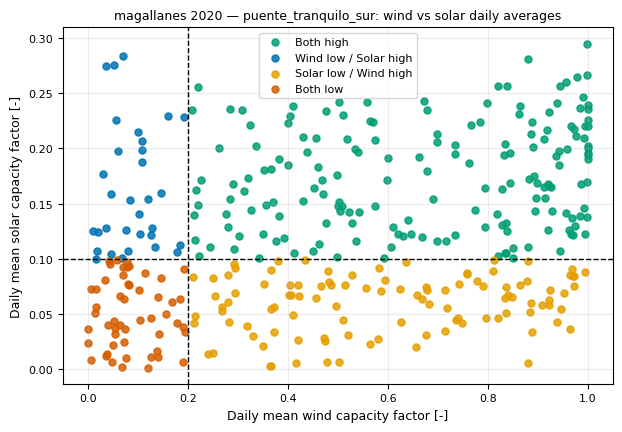

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2020_wind_vs_solar_daily_scatter.png


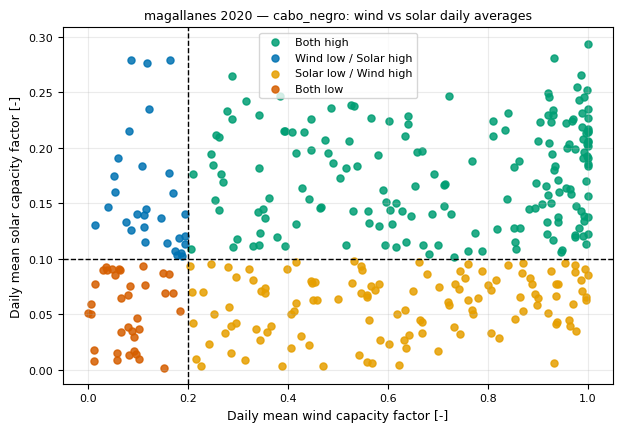

In [55]:

# Spatial plot 3: wind vs solar scatter for each site during the selected critical year
if PLOT_SPATIAL_COMPARISON:
    for site in spatial_summary_df["site"].tolist():
        site_df = spatial_daily_df[spatial_daily_df["site"] == site].copy()
        prefix = f"{CASE_NAME}_{site}_{critical_year}"
        plot_scatter(
            site_df,
            title=f"{CASE_NAME} {critical_year} — {site}: wind vs solar daily averages",
            filename_prefix=prefix,
        )


## Wind-solar complementarity at Cabo Negro

This section evaluates whether low wind conditions are compensated by solar, and vice versa. It does **not** change the critical-year selection rule. It is used as a diagnostic to interpret the residual risk represented by `both_low` days.

In [56]:
# Wind-solar complementarity metrics by year at MAIN_SITE
# Interpretation:
# - Lower or negative wind_solar_corr_daily suggests stronger temporal complementarity.
# - Higher one_low_one_high_share means low-resource conditions in one technology are often compensated by the other.
# - both_low_share is the residual low-resource risk relevant for storage/backup.

if PLOT_COMPLEMENTARITY:

    comp_rows = []

    for year, group in main_daily_df.groupby("year"):
        g = group.sort_index().copy()

        either_low = g["wind_low"] | g["solar_low"]
        one_low_one_high = (g["wind_low"] & ~g["solar_low"]) | (~g["wind_low"] & g["solar_low"])

        comp_rows.append({
            "year": int(year),
            "site": MAIN_SITE,
            "wind_solar_corr_daily": float(g["wind_cf"].corr(g["solar_cf"])),
            "both_low_days": int(g["both_low"].sum()),
            "both_low_share": float(g["both_low"].mean()),
            "one_low_one_high_days": int(one_low_one_high.sum()),
            "one_low_one_high_share": float(one_low_one_high.mean()),
            "compensation_share_given_either_low": (
                float(one_low_one_high.sum() / either_low.sum()) if either_low.sum() else np.nan
            ),
            "wind_low_days": int(g["wind_low"].sum()),
            "solar_low_days": int(g["solar_low"].sum()),
            "mean_wind_cf": float(g["wind_cf"].mean()),
            "mean_solar_cf": float(g["solar_cf"].mean()),
        })

    wind_solar_complementarity_df = pd.DataFrame(comp_rows).sort_values("year")

    wind_solar_comp_csv = TABLES_DIR / f"{CASE_NAME}_{MAIN_SITE}_wind_solar_complementarity_by_year.csv"
    wind_solar_complementarity_df.to_csv(wind_solar_comp_csv, index=False)

    print(f"Saved: {wind_solar_comp_csv}")
    display(wind_solar_complementarity_df)


Saved: output_critical_weather_year\tables\magallanes_cabo_negro_wind_solar_complementarity_by_year.csv


,year,site,wind_solar_corr_daily,both_low_days,both_low_share,one_low_one_high_days,one_low_one_high_share,compensation_share_given_either_low,wind_low_days,solar_low_days,mean_wind_cf,mean_solar_cf
0,2016,cabo_negro,0.187490,39,0.106557,122,0.333333,0.757764,72,128,0.554993,0.133308
1,2017,cabo_negro,0.088942,21,0.057534,153,0.419178,0.879310,55,140,0.604786,0.129612
2,2018,cabo_negro,0.217901,27,0.073973,134,0.367123,0.832298,61,127,0.583196,0.131558
3,2019,cabo_negro,0.213670,22,0.060274,140,0.383562,0.864198,50,134,0.607227,0.130868
4,2020,cabo_negro,0.255820,36,0.098361,153,0.418033,0.809524,66,159,0.576391,0.122746
5,2021,cabo_negro,0.177106,30,0.082192,138,0.378082,0.821429,56,142,0.609905,0.129196
6,2022,cabo_negro,0.149715,24,0.065753,138,0.378082,0.851852,50,136,0.607838,0.132339
7,2023,cabo_negro,0.241548,18,0.049315,129,0.353425,0.877551,30,135,0.644045,0.134559
8,2024,cabo_negro,0.277767,42,0.114754,123,0.336066,0.745455,66,141,0.588746,0.126300
9,2025,cabo_negro,0.249889,32,0.087671,121,0.331507,0.790850,61,124,0.599775,0.132440


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_wind_solar_daily_correlation_by_year.png


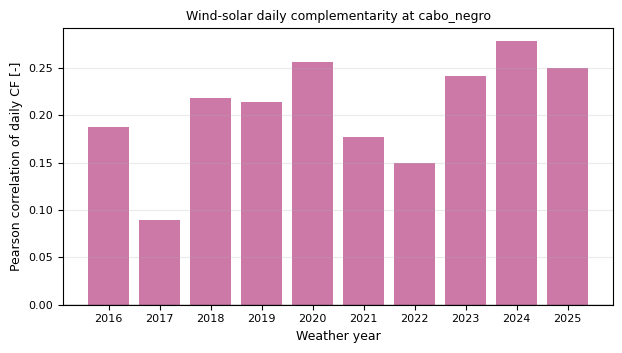

In [57]:
# Plot: daily wind-solar correlation by year

if PLOT_COMPLEMENTARITY:

    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    ax.bar(
        wind_solar_complementarity_df["year"].astype(str),
        wind_solar_complementarity_df["wind_solar_corr_daily"],
        color=OKABE_ITO["reddish_purple"],
    )

    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_title(f"Wind-solar daily complementarity at {MAIN_SITE}")
    ax.set_xlabel("Weather year")
    ax.set_ylabel("Pearson correlation of daily CF [-]")
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_wind_solar_daily_correlation_by_year.png")
    plt.show()


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_wind_solar_complementarity_shares_by_year.png


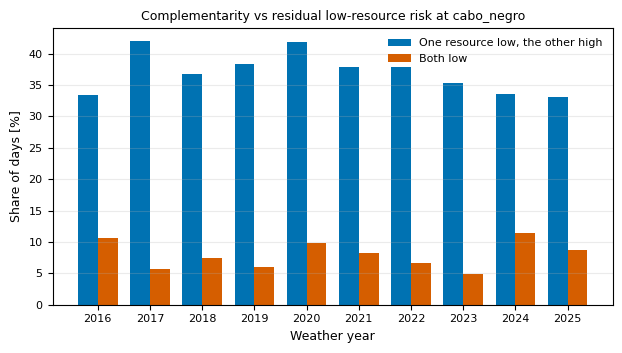

In [58]:
# Plot: share of one-low/one-high days vs both-low days

if PLOT_COMPLEMENTARITY:

    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    x = np.arange(len(wind_solar_complementarity_df))
    width = 0.38

    ax.bar(
        x - width / 2,
        100 * wind_solar_complementarity_df["one_low_one_high_share"],
        width=width,
        color=OKABE_ITO["blue"],
        label="One resource low, the other high",
    )

    ax.bar(
        x + width / 2,
        100 * wind_solar_complementarity_df["both_low_share"],
        width=width,
        color=category_colors["both_low"],
        label="Both low",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(wind_solar_complementarity_df["year"].astype(str), rotation=0)
    ax.set_title(f"Complementarity vs residual low-resource risk at {MAIN_SITE}")
    ax.set_xlabel("Weather year")
    ax.set_ylabel("Share of days [%]")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_wind_solar_complementarity_shares_by_year.png")
    plt.show()


## Spatial complementarity within the Punta Arenas supply area

This section compares the selected Punta Arenas sites during the critical year selected from Cabo Negro. The aim is to test whether low-resource periods are spatially synchronized or whether other nearby sites provide some relief when Cabo Negro is both-low.

In [59]:
# Pairwise spatial complementarity during the selected critical year
# Uses only the Punta Arenas-focused sites in SPATIAL_SITES.

if PLOT_COMPLEMENTARITY and PLOT_SPATIAL_COMPARISON:

    spatial_comp_df = daily_sites_df[
        (daily_sites_df["year"] == critical_year)
        & (daily_sites_df["site"].isin(SPATIAL_SITES))
    ].copy()

    # Pivot daily CF and low-resource indicators by site
    wind_pivot = spatial_comp_df.pivot_table(
        index=spatial_comp_df.index,
        columns="site",
        values="wind_cf",
        aggfunc="mean",
    ).reindex(columns=SPATIAL_SITES)

    solar_pivot = spatial_comp_df.pivot_table(
        index=spatial_comp_df.index,
        columns="site",
        values="solar_cf",
        aggfunc="mean",
    ).reindex(columns=SPATIAL_SITES)

    both_low_pivot = spatial_comp_df.pivot_table(
        index=spatial_comp_df.index,
        columns="site",
        values="both_low",
        aggfunc="max",
    ).reindex(columns=SPATIAL_SITES).astype(bool)

    wind_corr = wind_pivot.corr()
    solar_corr = solar_pivot.corr()

    # Jaccard overlap of both-low days: intersection / union
    sites = list(both_low_pivot.columns)
    jaccard = pd.DataFrame(index=sites, columns=sites, dtype=float)

    for s1 in sites:
        for s2 in sites:
            a = both_low_pivot[s1].fillna(False)
            b = both_low_pivot[s2].fillna(False)
            union = (a | b).sum()
            jaccard.loc[s1, s2] = ((a & b).sum() / union) if union else np.nan

    # For each site, how often is it not both-low when MAIN_SITE is both-low?
    main_mask = both_low_pivot[MAIN_SITE].fillna(False)

    main_low_relieved = []

    for site in sites:
        site_mask = both_low_pivot[site].fillna(False)

        main_low_relieved.append({
            "site": site,
            "critical_year": critical_year,
            "main_site_both_low_days": int(main_mask.sum()),
            "site_also_both_low_days": int((main_mask & site_mask).sum()),
            "site_not_both_low_when_main_is_both_low_days": int((main_mask & ~site_mask).sum()),
            "relief_share_when_main_is_both_low": (
                float((main_mask & ~site_mask).sum() / main_mask.sum())
                if main_mask.sum()
                else np.nan
            ),
        })

    relief_df = pd.DataFrame(main_low_relieved).sort_values(
        "relief_share_when_main_is_both_low",
        ascending=False,
    )

    wind_corr_csv = TABLES_DIR / f"{CASE_NAME}_{critical_year}_punta_arenas_spatial_wind_corr_daily.csv"
    solar_corr_csv = TABLES_DIR / f"{CASE_NAME}_{critical_year}_punta_arenas_spatial_solar_corr_daily.csv"
    jaccard_csv = TABLES_DIR / f"{CASE_NAME}_{critical_year}_punta_arenas_spatial_both_low_jaccard.csv"
    relief_csv = TABLES_DIR / f"{CASE_NAME}_{critical_year}_punta_arenas_spatial_relief_when_{MAIN_SITE}_both_low.csv"

    wind_corr.to_csv(wind_corr_csv)
    solar_corr.to_csv(solar_corr_csv)
    jaccard.to_csv(jaccard_csv)
    relief_df.to_csv(relief_csv, index=False)

    print(f"Saved: {wind_corr_csv}")
    print(f"Saved: {solar_corr_csv}")
    print(f"Saved: {jaccard_csv}")
    print(f"Saved: {relief_csv}")

    print("Daily wind CF correlation:")
    display(wind_corr)

    print("Daily solar CF correlation:")
    display(solar_corr)

    print("Both-low Jaccard overlap:")
    display(jaccard)

    print(f"Relief when {MAIN_SITE} is both-low:")
    display(relief_df)


Saved: output_critical_weather_year\tables\magallanes_2020_punta_arenas_spatial_wind_corr_daily.csv
Saved: output_critical_weather_year\tables\magallanes_2020_punta_arenas_spatial_solar_corr_daily.csv
Saved: output_critical_weather_year\tables\magallanes_2020_punta_arenas_spatial_both_low_jaccard.csv
Saved: output_critical_weather_year\tables\magallanes_2020_punta_arenas_spatial_relief_when_cabo_negro_both_low.csv
Daily wind CF correlation:


site,cabo_negro,puente_tranquilo_sur
site,,
cabo_negro,1.000000,0.975753
puente_tranquilo_sur,0.975753,1.000000


Daily solar CF correlation:


site,cabo_negro,puente_tranquilo_sur
site,,
cabo_negro,1.000000,0.987403
puente_tranquilo_sur,0.987403,1.000000


Both-low Jaccard overlap:


,cabo_negro,puente_tranquilo_sur
cabo_negro,1.00000,0.62963
puente_tranquilo_sur,0.62963,1.00000


Relief when cabo_negro is both-low:


,site,critical_year,main_site_both_low_days,site_also_both_low_days,site_not_both_low_when_main_is_both_low_days,relief_share_when_main_is_both_low
1,puente_tranquilo_sur,2020,36,34,2,0.055556
0,cabo_negro,2020,36,36,0,0.000000


Saved: output_critical_weather_year\figures\magallanes_2020_punta_arenas_spatial_wind_daily_corr_heatmap.png


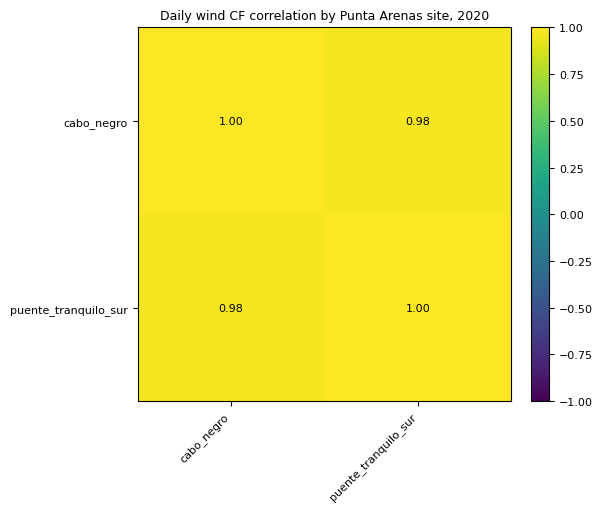

Saved: output_critical_weather_year\figures\magallanes_2020_punta_arenas_spatial_solar_daily_corr_heatmap.png


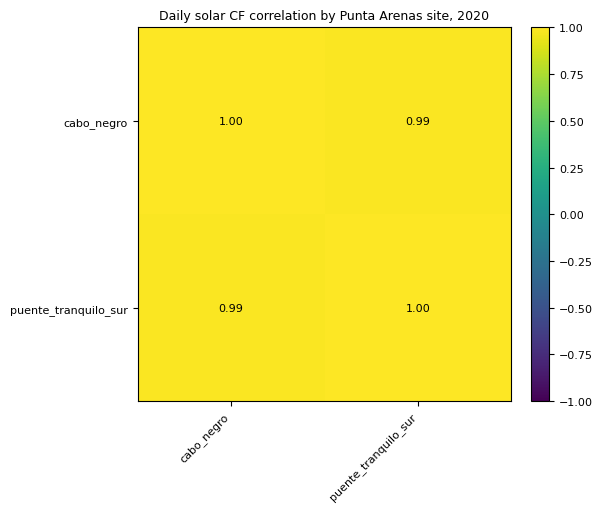

Saved: output_critical_weather_year\figures\magallanes_2020_punta_arenas_spatial_both_low_jaccard_heatmap.png


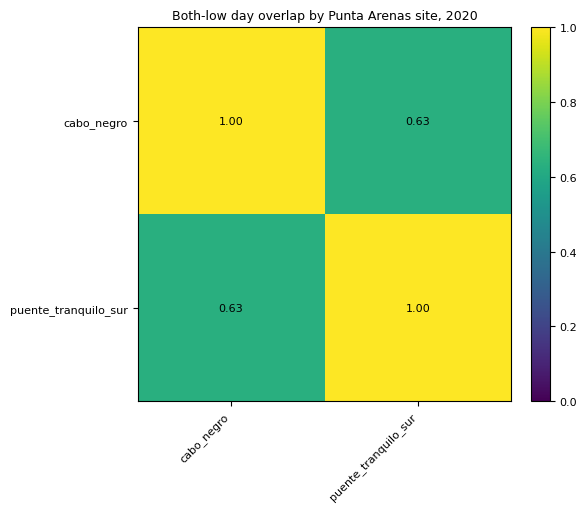

In [60]:
# Heatmaps for spatial complementarity matrices

def plot_matrix(matrix, title, filename, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)

    im = ax.imshow(matrix.values.astype(float), vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)
    ax.set_title(title)

    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            value = matrix.iloc[i, j]
            label = "" if pd.isna(value) else f"{value:.2f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=FONT_SIZE_SMALL)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    savefig(fig, filename)
    plt.show()


if PLOT_COMPLEMENTARITY and PLOT_SPATIAL_COMPARISON:

    plot_matrix(
        wind_corr,
        f"Daily wind CF correlation by Punta Arenas site, {critical_year}",
        f"{CASE_NAME}_{critical_year}_punta_arenas_spatial_wind_daily_corr_heatmap.png",
        vmin=-1,
        vmax=1,
    )

    plot_matrix(
        solar_corr,
        f"Daily solar CF correlation by Punta Arenas site, {critical_year}",
        f"{CASE_NAME}_{critical_year}_punta_arenas_spatial_solar_daily_corr_heatmap.png",
        vmin=-1,
        vmax=1,
    )

    plot_matrix(
        jaccard,
        f"Both-low day overlap by Punta Arenas site, {critical_year}",
        f"{CASE_NAME}_{critical_year}_punta_arenas_spatial_both_low_jaccard_heatmap.png",
        vmin=0,
        vmax=1,
    )


## Daily capacity-factor distributions

These plots are the capacity-factor distribution alternative suggested by Hadi. They combine violin plots with jittered daily points, showing the full spread of daily wind and solar CF rather than only maps or annual means.

In [61]:
# Capacity factor distribution plots: violin + jittered daily points
# Useful complement to heatmaps because they show the full distribution,
# not only the mean or a spatial map.

def plot_cf_violin_strip_by_resource(df, group_col, title, filename_prefix, order=None):
    """Plot daily CF distributions for wind and solar by group_col."""

    plot_df = df.copy()

    if order is None:
        order = list(pd.unique(plot_df[group_col]))

    resources = ["wind", "solar"]
    resource_cols = {
        "wind": "wind_cf",
        "solar": "solar_cf",
    }

    resource_colors = {
        "wind": tech_colors["wind"],
        "solar": tech_colors["solar"],
    }

    n_groups = len(order)
    x_positions = np.arange(n_groups)
    offsets = {
        "wind": -0.18,
        "solar": 0.18,
    }

    fig, ax = plt.subplots(figsize=(max(WORD_DOUBLE_COL_IN, 0.65 * n_groups + 2.5), FIGSIZE_STANDARD[1]))

    rng = np.random.default_rng(42)

    for resource in resources:
        data = [
            plot_df.loc[
                plot_df[group_col] == group,
                resource_cols[resource],
            ].dropna().values
            for group in order
        ]

        positions = x_positions + offsets[resource]

        if not any(len(values) > 0 for values in data):
            continue

        # matplotlib.violinplot cannot handle empty arrays, so use NaN placeholders.
        violin_data = [values if len(values) else np.array([np.nan]) for values in data]

        violin = ax.violinplot(
            violin_data,
            positions=positions,
            widths=0.30,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )

        for body in violin["bodies"]:
            body.set_facecolor(resource_colors[resource])
            body.set_edgecolor("black")
            body.set_alpha(0.32)
            body.set_linewidth(0.6)

        if "cmedians" in violin:
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.1)

        for pos, values in zip(positions, data):
            if len(values) == 0:
                continue

            jitter = rng.normal(0, 0.035, size=len(values))

            ax.scatter(
                np.full(len(values), pos) + jitter,
                values,
                s=9,
                alpha=0.35,
                color=resource_colors[resource],
                edgecolors="none",
            )

    ax.set_title(title)
    ax.set_ylabel("Daily mean capacity factor [-]")
    ax.set_xlabel(group_col.replace("_", " ").title())
    ax.set_xticks(x_positions)

    ax.set_xticklabels(
        [str(v) for v in order],
        rotation=45 if n_groups > 6 else 0,
        ha="right" if n_groups > 6 else "center",
    )

    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)

    handles = [
        Patch(
            facecolor=tech_colors["wind"],
            edgecolor="black",
            alpha=0.32,
            label="Wind",
        ),
        Patch(
            facecolor=tech_colors["solar"],
            edgecolor="black",
            alpha=0.32,
            label="Solar",
        ),
    ]

    ax.legend(handles=handles, frameon=False, ncol=2)

    plt.tight_layout()
    savefig(fig, f"{filename_prefix}_daily_cf_violin_strip.png")
    plt.show()


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_by_year_daily_cf_violin_strip.png


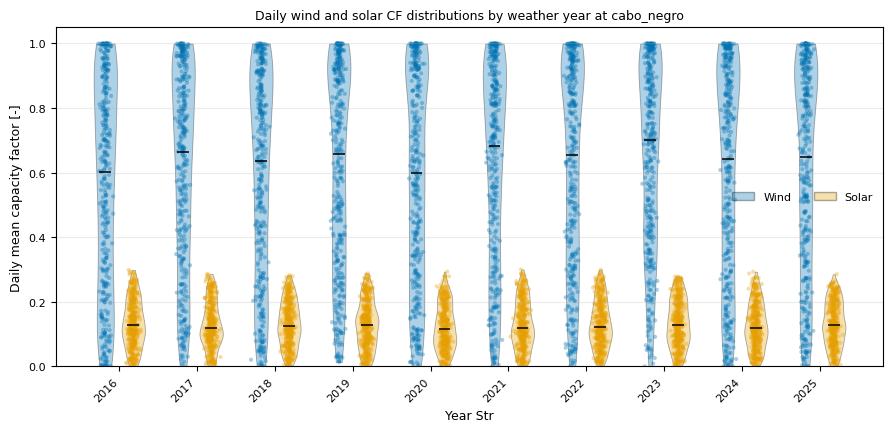

In [62]:
# Distribution by weather year at the main site

if PLOT_CF_DISTRIBUTIONS:

    main_distribution_df = main_daily_df.copy()
    main_distribution_df["year_str"] = main_distribution_df["year"].astype(str)

    plot_cf_violin_strip_by_resource(
        main_distribution_df,
        group_col="year_str",
        title=f"Daily wind and solar CF distributions by weather year at {MAIN_SITE}",
        filename_prefix=f"{CASE_NAME}_{MAIN_SITE}_by_year",
        order=[str(y) for y in sorted(main_distribution_df["year"].unique())],
    )


Saved: output_critical_weather_year\figures\magallanes_2020_punta_arenas_by_site_daily_cf_violin_strip.png


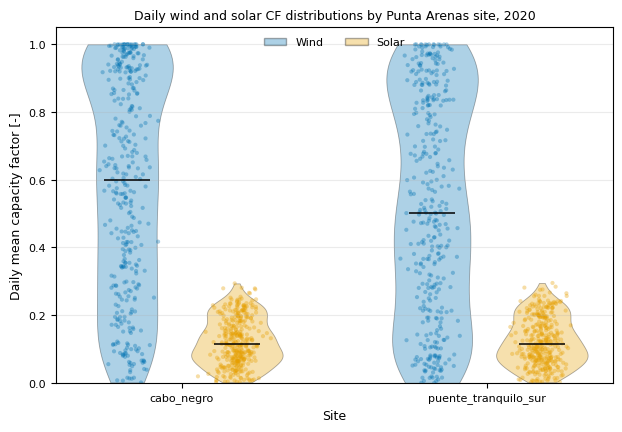

In [63]:
# Distribution by site during the selected critical year

if PLOT_CF_DISTRIBUTIONS and PLOT_SPATIAL_COMPARISON:

    spatial_distribution_df = daily_sites_df[
        (daily_sites_df["year"] == critical_year)
        & (daily_sites_df["site"].isin(SPATIAL_SITES))
    ].copy()

    plot_cf_violin_strip_by_resource(
        spatial_distribution_df,
        group_col="site",
        title=f"Daily wind and solar CF distributions by Punta Arenas site, {critical_year}",
        filename_prefix=f"{CASE_NAME}_{critical_year}_punta_arenas_by_site",
        order=SPATIAL_SITES,
    )


In [64]:

# Optional: threshold sensitivity at MAIN_SITE
# This does not recompute CF. It only reclassifies the existing daily wind/solar table.

sensitivity_thresholds = [
    (0.15, 0.10),
    (0.20, 0.12),
    (0.25, 0.15),
]

sensitivity_rows = []
base_daily_cf = main_daily_df[["year", "site", "wind_cf", "solar_cf"]].copy()

for wind_thr, solar_thr in sensitivity_thresholds:
    for year, group in base_daily_cf.groupby("year"):
        classified = classify_wind_solar_days(group[["wind_cf", "solar_cf"]], wind_thr, solar_thr)
        metrics = compute_metrics(classified, int(year), MAIN_SITE)
        sensitivity_rows.append({
            "wind_threshold": wind_thr,
            "solar_threshold": solar_thr,
            "site": MAIN_SITE,
            "year": int(year),
            "both_low_days": metrics["both_low_days"],
            "max_consecutive_both_low_days": metrics["max_consecutive_both_low_days"],
            "max_both_low_start": metrics["max_both_low_start"],
            "max_both_low_end": metrics["max_both_low_end"],
        })

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(
    ["wind_threshold", "solar_threshold", "max_consecutive_both_low_days", "both_low_days"],
    ascending=[True, True, False, False],
)

sensitivity_csv = TABLES_DIR / f"{CASE_NAME}_{MAIN_SITE}_threshold_sensitivity_{YEAR_RANGE_SUFFIX}.csv"
sensitivity_df.to_csv(sensitivity_csv, index=False)
print(f"Saved: {sensitivity_csv}")
display(sensitivity_df)


Saved: output_critical_weather_year\tables\magallanes_cabo_negro_threshold_sensitivity_2016_2025.csv


,wind_threshold,solar_threshold,site,year,both_low_days,max_consecutive_both_low_days,max_both_low_start,max_both_low_end
4,0.15,0.10,cabo_negro,2020,30,9,2020-06-28,2020-07-06
9,0.15,0.10,cabo_negro,2025,26,6,2025-07-28,2025-08-02
2,0.15,0.10,cabo_negro,2018,23,6,2018-06-09,2018-06-14
0,0.15,0.10,cabo_negro,2016,34,5,2016-05-28,2016-06-01
8,0.15,0.10,cabo_negro,2024,37,4,2024-05-06,2024-05-09
5,0.15,0.10,cabo_negro,2021,25,3,2021-05-06,2021-05-08
6,0.15,0.10,cabo_negro,2022,20,3,2022-07-03,2022-07-05
3,0.15,0.10,cabo_negro,2019,16,3,2019-07-09,2019-07-11
7,0.15,0.10,cabo_negro,2023,16,3,2023-06-20,2023-06-22
1,0.15,0.10,cabo_negro,2017,17,2,2017-05-06,2017-05-07
